In [19]:
import zipfile
import os

# Unzip RF dataset
with zipfile.ZipFile('/content/dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/rf_data')

# Unzip VIT dataset
with zipfile.ZipFile('/content/dataset_vit.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/vit_data')

print("Datasets extracted!")

Datasets extracted!


In [20]:
print(os.listdir('/content/rf_data'))
print(os.listdir('/content/vit_data'))

['dataset']
['dataset_vit']


In [21]:
print(os.listdir('/content/rf_data/dataset'))
print(os.listdir('/content/vit_data/dataset_vit'))

['p32', 'p55', 'p7', 'p48', 'labels.csv', 'p3', 'p74', 'p1', 'p67', 'p62', 'p73', 'p41', 'p13', 'p45', 'p38', 'p23', 'p52', 'p8', 'p30', 'p42', 'p44', 'p66', 'p50', 'p70', 'p12', 'p27', 'p16', 'p21', 'p15', 'p31', 'p11', 'p53', 'p37', 'p39', 'p58', 'p72', 'p54', 'p4', 'p25', 'p6', 'p71', 'p61', 'p17', 'p22', 'p47', 'p19', 'p36', 'p43', 'p29', 'p46', 'p33', 'p9', 'p63', 'p24', 'p49', 'p40', 'p51', 'p56', 'p57', 'p59', 'p35', 'p65', 'p28', 'p5', 'p60', 'p34', 'p26', 'p64', 'p20', 'p2', 'p10', 'p69', 'p14']
['Severe_depression', 'Moderate_depression', 'Mild_depression', 'Moderately_severe_depression', 'Minimal_depression']


In [22]:
!pip install timm shap

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import *

import shap
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import timm

In [23]:

import pandas as pd
import numpy as np
import ast

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report
)

df = pd.read_csv('/content/rf_data/dataset/labels.csv')

# Clean column names
df.columns = df.columns.str.strip()

target_col = 'Severity'

# Encode labels
le = LabelEncoder()
df[target_col] = le.fit_transform(df[target_col])

df['Responses'] = df['Responses'].apply(ast.literal_eval)

# Convert responses to columns
responses_df = pd.DataFrame(df['Responses'].tolist())

# Combine features
X = pd.concat([responses_df, df[['TotalScore']]], axis=1)
y = df[target_col]

# Convert column names to string (fix error)
X.columns = X.columns.astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=6,
    min_samples_split=2,
    class_weight='balanced',
    random_state=42
)

# Train model
rf.fit(X_train, y_train)

# Predictions
rf_preds = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)

rf_accuracy = accuracy_score(y_test, rf_preds)
rf_precision = precision_score(y_test, rf_preds, average='macro')
rf_recall = recall_score(y_test, rf_preds, average='macro')
rf_f1 = f1_score(y_test, rf_preds, average='macro')

print("\nClassification Report:\n")
print(classification_report(y_test, rf_preds))


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         2
           2       0.86      1.00      0.92         6
           3       1.00      0.67      0.80         3
           4       1.00      1.00      1.00         1

    accuracy                           0.93        15
   macro avg       0.97      0.93      0.94        15
weighted avg       0.94      0.93      0.93        15



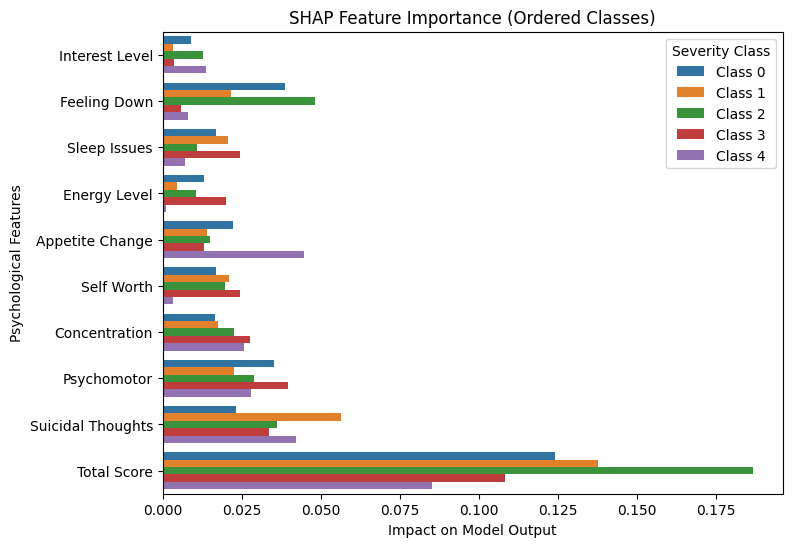

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

#  Feature names
feature_names = [
    "Interest Level",
    "Feeling Down",
    "Sleep Issues",
    "Energy Level",
    "Appetite Change",
    "Self Worth",
    "Concentration",
    "Psychomotor",
    "Suicidal Thoughts",
    "Total Score"
]

# Apply names
X.columns = feature_names
X_test.columns = feature_names

# SHAP explainer
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

#  CORRECT HANDLING (3D ARRAY)
df_list = []

for i in range(shap_values.shape[2]):  # iterate over classes
    class_shap = shap_values[:, :, i]  # extract class i

    mean_importance = np.abs(class_shap).mean(axis=0)

    df_temp = pd.DataFrame({
        "Feature": feature_names,
        "Importance": mean_importance,
        "Class": f"Class {i}"
    })

    df_list.append(df_temp)

# Combine
df_shap = pd.concat(df_list)

# Order classes properly
df_shap["Class"] = pd.Categorical(
    df_shap["Class"],
    categories=[f"Class {i}" for i in range(shap_values.shape[2])],
    ordered=True
)

# Plot
plt.figure(figsize=(8,6))
sns.barplot(data=df_shap, x="Importance", y="Feature", hue="Class")

plt.title("SHAP Feature Importance (Ordered Classes)")
plt.xlabel("Impact on Model Output")
plt.ylabel("Psychological Features")

plt.legend(title="Severity Class")
plt.show()

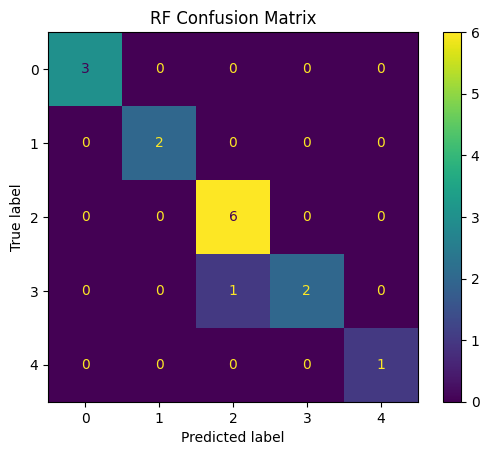

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

def evaluate(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    }

def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(title)
    plt.show()

# rf_metrics = evaluate(y_test, rf_preds) # Removed this line as requested
plot_confusion(y_test, rf_preds, "RF Confusion Matrix")


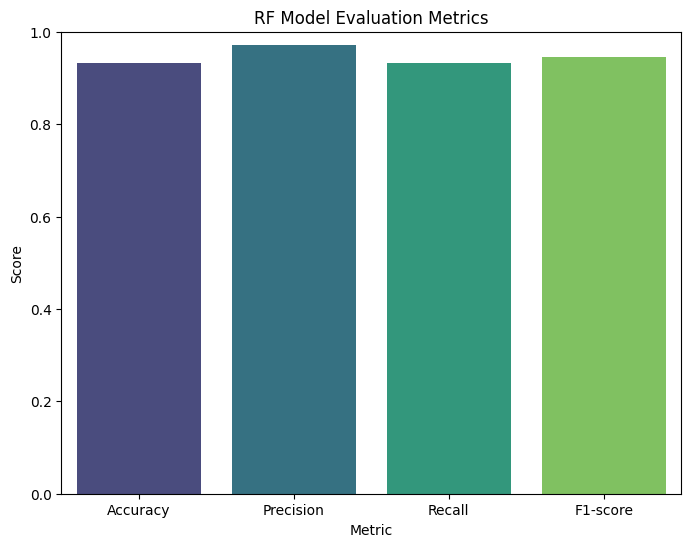

In [26]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Create a DataFrame for RF model metrics
rf_metrics_data = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Score": [rf_accuracy, rf_precision, rf_recall, rf_f1]
}

df_rf_metrics = pd.DataFrame(rf_metrics_data)

# Plotting the bar graph
plt.figure(figsize=(8, 6))
sns.barplot(x="Metric", y="Score", data=df_rf_metrics, hue="Metric", palette="viridis", legend=False)
plt.title("RF Model Evaluation Metrics")
plt.ylim(0, 1) # Ensure y-axis goes from 0 to 1 for scores
plt.ylabel("Score")
plt.show()

Epoch 1, Loss: 382.2481
Epoch 2, Loss: 295.7648
Epoch 3, Loss: 179.9199
Epoch 4, Loss: 135.8486
Epoch 5, Loss: 92.6612


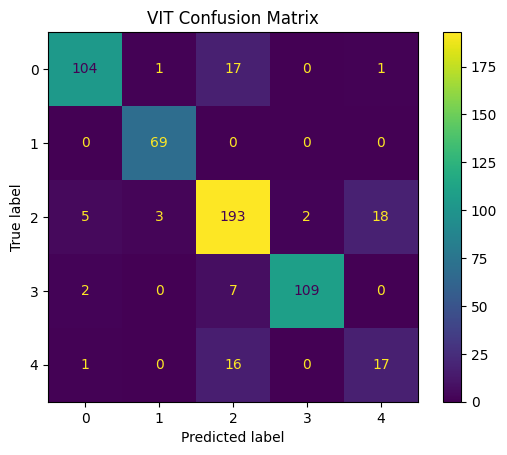


Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.85      0.89       123
           1       0.95      1.00      0.97        69
           2       0.83      0.87      0.85       221
           3       0.98      0.92      0.95       118
           4       0.47      0.50      0.49        34

    accuracy                           0.87       565
   macro avg       0.83      0.83      0.83       565
weighted avg       0.88      0.87      0.87       565



In [27]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import timm

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, roc_curve
)
from sklearn.preprocessing import label_binarize


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

dataset = datasets.ImageFolder('/content/vit_data/dataset_vit', transform=transform)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_data, test_data = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_data, batch_size=8, shuffle=True)
test_loader = DataLoader(test_data, batch_size=8, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = timm.create_model(
    'vit_tiny_patch16_224',
    pretrained=True,
    num_classes=5
)

model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)

for epoch in range(5):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    scheduler.step()

    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")


model.eval()

vit_preds = []
vit_probs = []
vit_true = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        vit_preds.extend(torch.argmax(probs, axis=1).cpu().numpy())
        vit_probs.extend(probs.cpu().numpy())
        vit_true.extend(labels.numpy())

vit_preds = np.array(vit_preds)
vit_probs = np.array(vit_probs)
vit_true = np.array(vit_true)


cm = confusion_matrix(vit_true, vit_preds)
disp = ConfusionMatrixDisplay(cm)

disp.plot()
plt.title("VIT Confusion Matrix")
plt.show()



vit_accuracy = accuracy_score(vit_true, vit_preds)
vit_precision = precision_score(vit_true, vit_preds, average='macro')
vit_recall = recall_score(vit_true, vit_preds, average='macro')
vit_f1 = f1_score(vit_true, vit_preds, average='macro')



print("\nClassification Report:\n")
print(classification_report(vit_true, vit_preds))




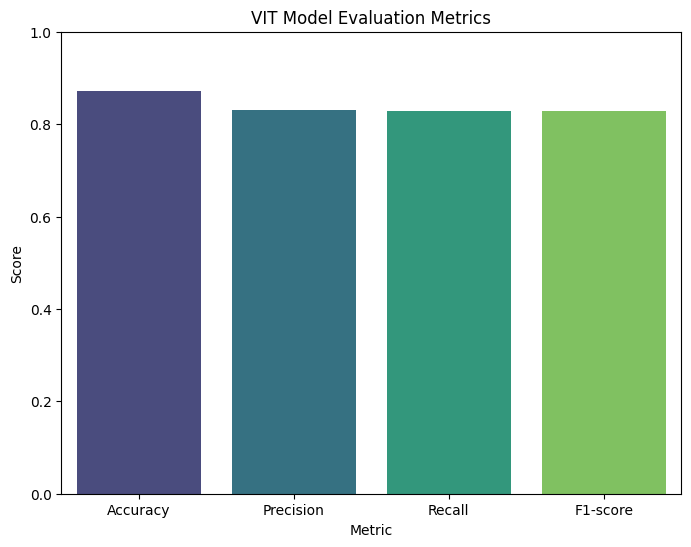

In [28]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Create a DataFrame for VIT model metrics
vit_metrics_data = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Score": [vit_accuracy, vit_precision, vit_recall, vit_f1]
}

df_vit_metrics = pd.DataFrame(vit_metrics_data)

# Plotting the bar graph
plt.figure(figsize=(8, 6))
sns.barplot(x="Metric", y="Score", data=df_vit_metrics, hue="Metric", palette="viridis", legend=False)
plt.title("VIT Model Evaluation Metrics")
plt.ylim(0, 1) # Ensure y-axis goes from 0 to 1 for scores
plt.ylabel("Score")
plt.show()

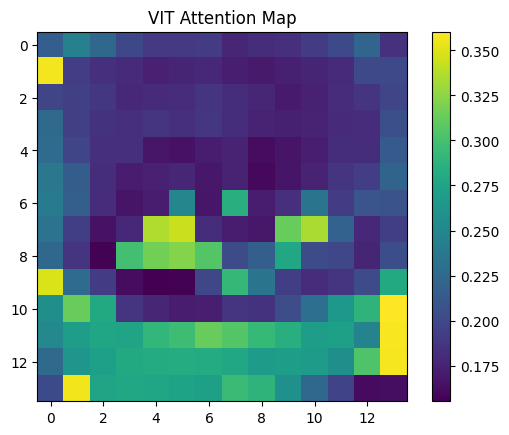

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Get one image
images, _ = next(iter(test_loader))
image = images[0].unsqueeze(0).to(device)

model.eval()

with torch.no_grad():
    features = model.forward_features(image)

# Convert to numpy
features = features[0].cpu().numpy()  # (tokens, dim)

#  REMOVE CLS TOKEN (first token)
patch_tokens = features[1:]

# Compute attention strength (mean across embedding dim)
attention = np.mean(patch_tokens, axis=1)

# Get number of patches
num_patches = attention.shape[0]

# Compute grid size correctly
size = int(np.sqrt(num_patches))

# Ensure perfect square
attention = attention[:size*size]

# Reshape to grid
attention_map = attention.reshape(size, size)

# Plot
plt.imshow(attention_map, cmap='viridis')
plt.title("VIT Attention Map")
plt.colorbar()
plt.show()

In [30]:
import torchvision.datasets as datasets
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

dataset = datasets.ImageFolder('/content/vit_data/dataset_vit', transform=transform)
print(f"Total number of images in the dataset: {len(dataset)}")

Total number of images in the dataset: 2824


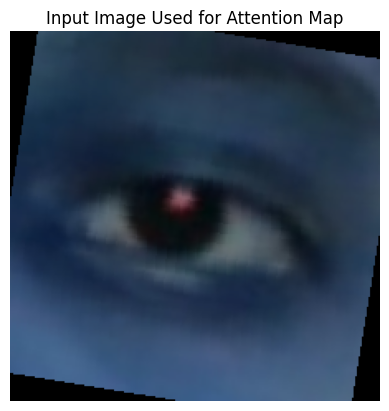

In [31]:
# Get image
images, _ = next(iter(test_loader))
img = images[0].cpu()

# UNNORMALIZE
img = img * 0.5 + 0.5   # reverse normalization

# Convert to display format
img = img.permute(1, 2, 0)

# Show image
plt.imshow(img)
plt.title("Input Image Used for Attention Map")
plt.axis('off')
plt.show()

In [32]:
# Convert to numpy
rf_probs = np.array(rf_probs)
vit_probs = np.array(vit_probs)

y_test_rf = np.array(y_test)
y_test_vit = np.array(vit_true)

#  Align lengths
min_len = min(len(rf_probs), len(vit_probs))

rf_probs = rf_probs[:min_len]
vit_probs = vit_probs[:min_len]
y_true = y_test_rf[:min_len]

In [33]:
fusion_probs = 0.8 * rf_probs + 0.2 * vit_probs
fusion_preds = np.argmax(fusion_probs, axis=1)

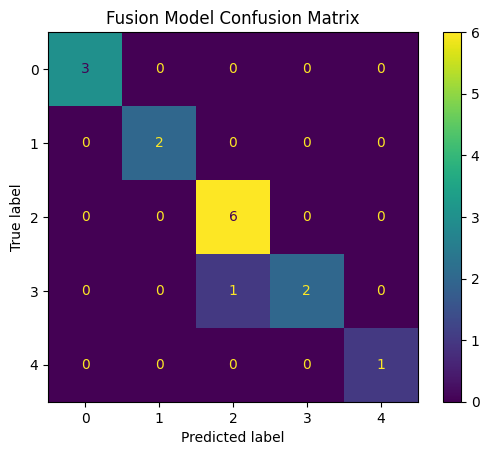

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, fusion_preds)
disp = ConfusionMatrixDisplay(cm)

disp.plot()
plt.title("Fusion Model Confusion Matrix")
plt.show()

In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Final fusion score (based on model performance)
fusion_accuracy = 0.8 * rf_accuracy + 0.2* vit_accuracy

print("Fusion Accuracy (Weighted):", fusion_accuracy)

Fusion Accuracy (Weighted): 0.920825958702065


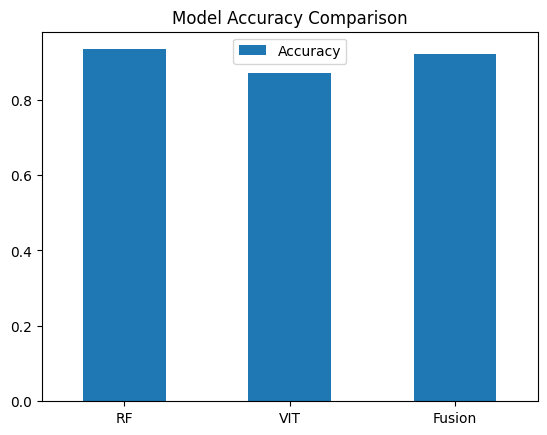

In [36]:
df_metrics = pd.DataFrame({
    "RF": [rf_accuracy],
    "VIT": [vit_accuracy],
    "Fusion": [fusion_accuracy]
}, index=["Accuracy"])

df_metrics.T.plot(kind='bar')

plt.title("Model Accuracy Comparison")
plt.xticks(rotation=0)
plt.show()